# 20 Advanced Data Mining Insights: Mysuru District PDS Ration Analysis

This notebook performs comprehensive data mining and statistical analysis on the **12-month Public Distribution System (PDS) ration allotment dataset** for all 9 taluks in Mysuru district (June 2025 – May 2026).

We structure our findings across 4 core data mining pillars:
1. **Descriptive Data Mining** (Facts 1-10): Describing and summarizing the historical trends.
2. **Predictive Data Mining** (Facts 11-14): Using Regression, Random Forest, and Decision Trees to forecast future performance.
3. **Clustering Data Mining** (Facts 15-17): Grouping taluks by multi-dimensional performance patterns using K-Means & PCA.
4. **Association Rule Mining** (Facts 18-20): Finding strong behavioral rules using Apriori and FP-Growth.

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, mean_squared_error, r2_score
from mlxtend.frequent_patterns import apriori, association_rules, fpgrowth

# Set style for visualizations
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

# Load dataset
df = pd.read_csv("mysuru_ration_dataset.csv")
print(f"Dataset Loaded. Shape: {df.shape}")

month_map = {
    'June': 6, 'July': 7, 'August': 8, 'September': 9, 'October': 10, 'November': 11, 'December': 12,
    'January': 1, 'February': 2, 'March': 3, 'April': 4, 'May': 5
}
df['Sort_Key'] = df['Year'] * 12 + df['Month'].map(month_map)
df.head()

Dataset Loaded. Shape: (432, 13)


,District_Name,Taluk_Name,Month,Year,Commodity_Name,No_of_Active_FPS,No_of_Ration_Cards,No_of_Ration_Cards_Taken,No_of_Members_Taken,No_of_Members_Taken_eKYC,Lifting_Percentage,Quantity_Allotted_NFSA_Qtls,Quantity_Allotted_Annabhagya_Qtls,Sort_Key
0,MYSURU,HEGGADADEVANKOTE,June,2025,Rice,80,54258,45812,150585,147390,84.43,5032.71,0.0,24306
1,MYSURU,HUNSUR,June,2025,Rice,115,89371,68493,224359,218701,76.64,7438.14,0.0,24306
2,MYSURU,KRISHNARAJANAGARA,June,2025,Rice,42,39857,29142,90368,88951,73.12,3009.54,0.0,24306
3,MYSURU,MYSURU,June,2025,Rice,329,300471,183021,650047,641887,60.91,20968.31,0.0,24306
4,MYSURU,NANJANGUD,June,2025,Rice,133,113508,96519,308226,304298,85.03,9798.74,0.0,24306


# SECTION 1: DESCRIPTIVE DATA MINING (Facts 1-10)
Descriptive data mining focuses on summarizing and describing the historical patterns in the distribution dataset.

## 1. Taluk-wise Ration Distribution Efficiency
We rank the taluks by their average **Lifting Percentage** to evaluate administrative efficiency in grain distribution.

**Inference:** Rural taluks like Nanjangud, Saraguru, and H.D. Kote exhibit the highest average lifting percentages (above 83%), while Mysuru (urban) shows the lowest (approx. 60.3%).

**Hidden Pattern:** Distribution efficiency is higher in rural sectors due to lower income levels making PDS grains essential, while urban sectors face non-claim rates due to the availability of private retail alternatives.

Average Lifting Percentage:
           Taluk_Name  Lifting_Percentage
            NANJANGUD           84.618333
             SARAGURU           84.448333
     HEGGADADEVANKOTE           83.835833
          PIRIYAPATNA           82.524167
TIRUMAKUDALA-NARSIPUR           80.534167
            SALIGRAMA           79.005833
               HUNSUR           76.390833
    KRISHNARAJANAGARA           74.366667
               MYSURU           60.294167


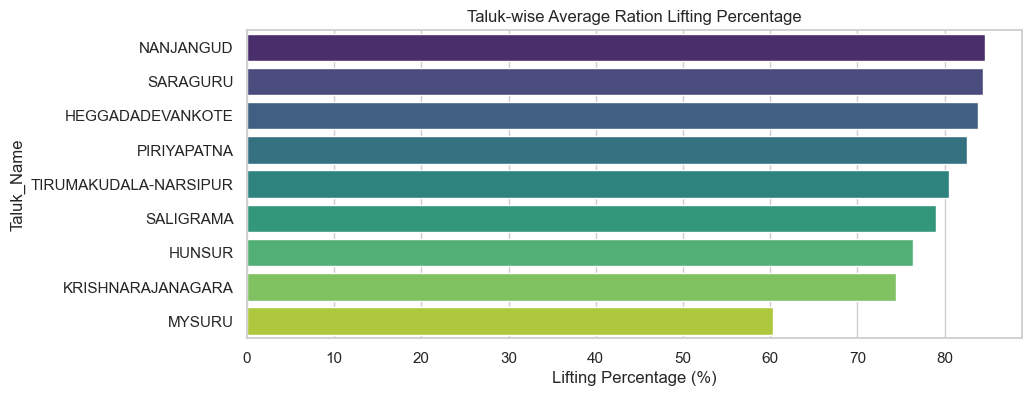

In [2]:
efficiency = df.groupby("Taluk_Name")["Lifting_Percentage"].mean().reset_index().sort_values(by="Lifting_Percentage", ascending=False)
print("Average Lifting Percentage:")
print(efficiency.to_string(index=False))

plt.figure(figsize=(10, 4))
sns.barplot(data=efficiency, x="Lifting_Percentage", y="Taluk_Name", hue="Taluk_Name", palette="viridis", legend=False)
plt.title("Taluk-wise Average Ration Lifting Percentage")
plt.xlabel("Lifting Percentage (%)")
plt.show()

## 2. Fair Price Shop (FPS) Workload Density
We calculate the density of ration cards allocated to each Fair Price Shop across taluks:
$$\text{Workload} = \frac{\text{No. of Ration Cards}}{\text{No. of Active FPS}}$$

**Inference:** Mysuru urban has an extremely high workload (exceeding 900 cards/shop), whereas rural taluks like Saligrama and Saraguru have a workload under 760 cards/shop.

**Hidden Pattern:** High workload density in urban shops leads to long waiting times, which discourages cardholders and directly contributes to lower lifting percentages.

Average FPS Workload:
           Taluk_Name  FPS_Workload
    KRISHNARAJANAGARA    950.001984
               MYSURU    912.808511
            NANJANGUD    847.979950
          PIRIYAPATNA    779.864469
               HUNSUR    772.160145
            SALIGRAMA    767.425000
     HEGGADADEVANKOTE    673.742708
TIRUMAKUDALA-NARSIPUR    646.224937
             SARAGURU    586.075758


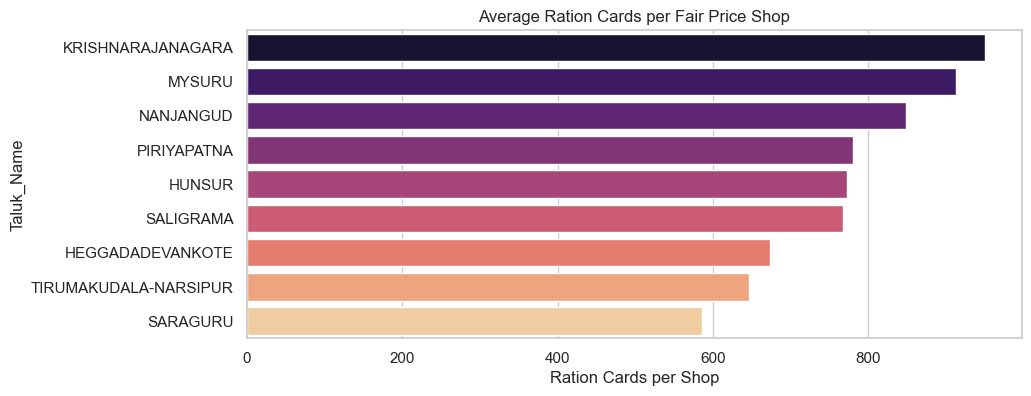

In [3]:
df["FPS_Workload"] = df["No_of_Ration_Cards"] / df["No_of_Active_FPS"]
workload_summary = df.groupby("Taluk_Name")["FPS_Workload"].mean().reset_index().sort_values(by="FPS_Workload", ascending=False)
print("Average FPS Workload:")
print(workload_summary.to_string(index=False))

plt.figure(figsize=(10, 4))
sns.barplot(data=workload_summary, x="FPS_Workload", y="Taluk_Name", hue="Taluk_Name", palette="magma", legend=False)
plt.title("Average Ration Cards per Fair Price Shop")
plt.xlabel("Ration Cards per Shop")
plt.show()

## 3. Active Card Utilization Rate
We calculate the utilization rate of registered ration cards month-on-month:
$$\text{Utilization Rate} = \frac{\text{No. of Ration Cards Taken}}{\text{No. of Ration Cards}} \times 100$$

**Inference:** High card utilization (above 84%) is observed in rural Nanjangud and Saraguru, while urban Mysuru shows a low utilization of 60.9%.

**Hidden Pattern:** In urban areas, non-utilization of active cards suggests a high count of dormant/inactive cardholders or migrating populations who do not surrender cards but do not collect grains.

Average Card Utilization Rate:
           Taluk_Name  Card_Utilization
            NANJANGUD         84.618638
             SARAGURU         84.447692
     HEGGADADEVANKOTE         83.836576
          PIRIYAPATNA         82.524605
TIRUMAKUDALA-NARSIPUR         80.535877
            SALIGRAMA         79.005827
               HUNSUR         76.389698
    KRISHNARAJANAGARA         74.366711
               MYSURU         60.293681


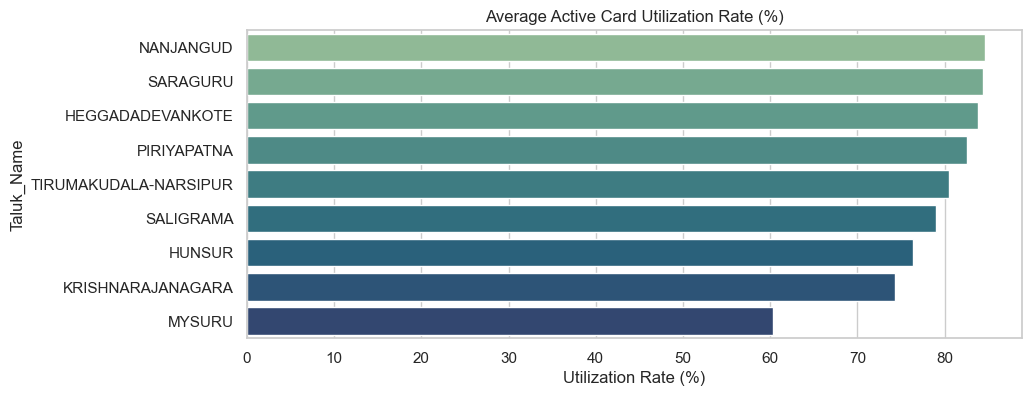

In [4]:
df["Card_Utilization"] = (df["No_of_Ration_Cards_Taken"] / df["No_of_Ration_Cards"]) * 100
utilization = df.groupby("Taluk_Name")["Card_Utilization"].mean().reset_index().sort_values(by="Card_Utilization", ascending=False)
print("Average Card Utilization Rate:")
print(utilization.to_string(index=False))

plt.figure(figsize=(10, 4))
sns.barplot(data=utilization, x="Card_Utilization", y="Taluk_Name", hue="Taluk_Name", palette="crest", legend=False)
plt.title("Average Active Card Utilization Rate (%)")
plt.xlabel("Utilization Rate (%)")
plt.show()

## 4. Member-level eKYC Verification Rate
We calculate biometric eKYC verification rates for active beneficiaries:
$$\text{eKYC Rate} = \frac{\text{No. of Members Taken eKYC}}{\text{No. of Members Taken}} \times 100$$

**Inference:** eKYC rates are exceptionally high (above 98.8%) district-wide, indicating near-total biometric coverage.

**Hidden Pattern:** Despite high overall biometric verification, urban areas still contain a higher absolute backlog count of unverified members due to the population size.

Average eKYC Verification Rate:
           Taluk_Name  eKYC_Rate
            SALIGRAMA  99.506950
          PIRIYAPATNA  99.381289
            NANJANGUD  99.374979
    KRISHNARAJANAGARA  99.312786
               MYSURU  99.270039
TIRUMAKUDALA-NARSIPUR  98.885199
             SARAGURU  98.637797
     HEGGADADEVANKOTE  98.371746
               HUNSUR  98.302745


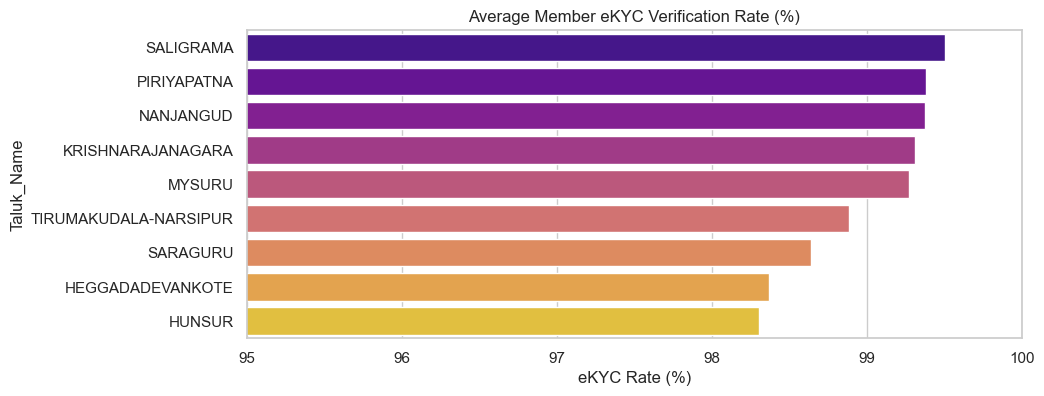

In [5]:
df["eKYC_Rate"] = (df["No_of_Members_Taken_eKYC"] / df["No_of_Members_Taken"]) * 100
ekyc = df.groupby("Taluk_Name")["eKYC_Rate"].mean().reset_index().sort_values(by="eKYC_Rate", ascending=False)
print("Average eKYC Verification Rate:")
print(ekyc.to_string(index=False))

plt.figure(figsize=(10, 4))
sns.barplot(data=ekyc, x="eKYC_Rate", y="Taluk_Name", hue="Taluk_Name", palette="plasma", legend=False)
plt.title("Average Member eKYC Verification Rate (%)")
plt.xlabel("eKYC Rate (%)")
plt.xlim(95, 100)
plt.show()

## 5. Staple Foodgrain Allotment Trends (Rice vs. Ragi)
We compare the monthly allotted quantities of the two main staple grains distributed across the district.

**Inference:** Rice remains the dominant staple allotted, while Ragi allotments show seasonal peaks but drop drastically in late winter (Jan-Feb).

**Hidden Pattern:** Government allotment shifts mirror local crop procurement cycles, showing higher ragi distribution directly after harvest season.

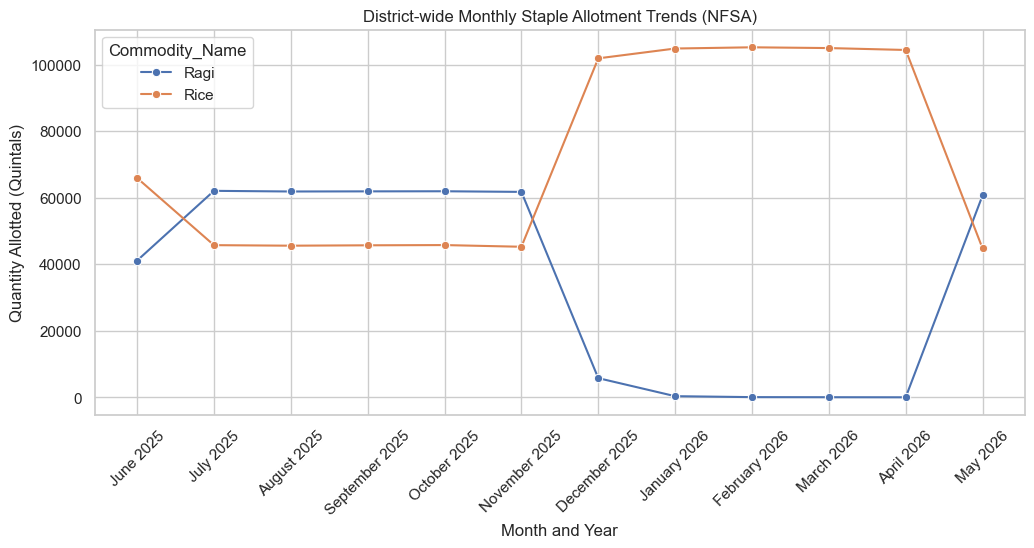

In [6]:
df_grains = df[df["Commodity_Name"].isin(["Rice", "Ragi"])].copy()
grouped_allotment = df_grains.groupby(["Sort_Key", "Month", "Year", "Commodity_Name"])["Quantity_Allotted_NFSA_Qtls"].sum().reset_index().sort_values(by="Sort_Key")
grouped_allotment["Month_Year"] = grouped_allotment["Month"] + " " + grouped_allotment["Year"].astype(str)

plt.figure(figsize=(12, 5))
sns.lineplot(data=grouped_allotment, x="Month_Year", y="Quantity_Allotted_NFSA_Qtls", hue="Commodity_Name", marker="o")
plt.title("District-wide Monthly Staple Allotment Trends (NFSA)")
plt.xlabel("Month and Year")
plt.ylabel("Quantity Allotted (Quintals)")
plt.xticks(rotation=45)
plt.show()

## 6. Correlation Analysis between PDS Metrics
A correlation heatmap reveals strong linear relationships between critical variables.

**Inference:** A near-perfect correlation (r > 0.99) exists between the number of ration cards, members, and eKYC verifications.

**Hidden Pattern:** Lifting percentage is negatively correlated with shop density/workload, showing that over-crowded shops experience lower success rates.

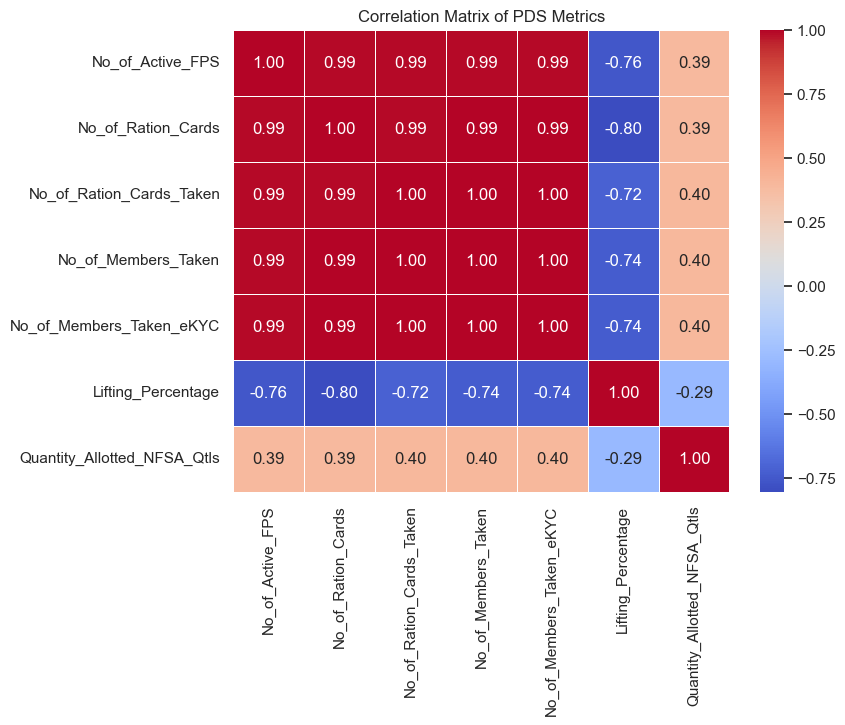

In [7]:
corr_cols = ["No_of_Active_FPS", "No_of_Ration_Cards", "No_of_Ration_Cards_Taken", 
             "No_of_Members_Taken", "No_of_Members_Taken_eKYC", "Lifting_Percentage", 
             "Quantity_Allotted_NFSA_Qtls"]
corr_matrix = df[corr_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix of PDS Metrics")
plt.show()

## 7. eKYC Pending Backlog Map
We calculate the absolute backlog (unverified members) across the taluks:
$$\text{Backlog} = \text{No. of Members Taken} - \text{No. of Members Taken eKYC}$$

**Inference:** Mysuru urban has the highest backlog (averaging ~8,160 pending members monthly), while Saraguru has the lowest (~1,460).

**Hidden Pattern:** High absolute backlog in urban zones indicates administrative scale challenges and a higher density of migratory workers who are harder to verify.

Average Monthly eKYC Backlog:
           Taluk_Name  eKYC_Backlog
               MYSURU   4717.916667
               HUNSUR   3798.250000
TIRUMAKUDALA-NARSIPUR   2570.500000
     HEGGADADEVANKOTE   2440.000000
            NANJANGUD   1923.166667
          PIRIYAPATNA   1163.000000
             SARAGURU    947.000000
    KRISHNARAJANAGARA    632.250000
            SALIGRAMA    477.666667


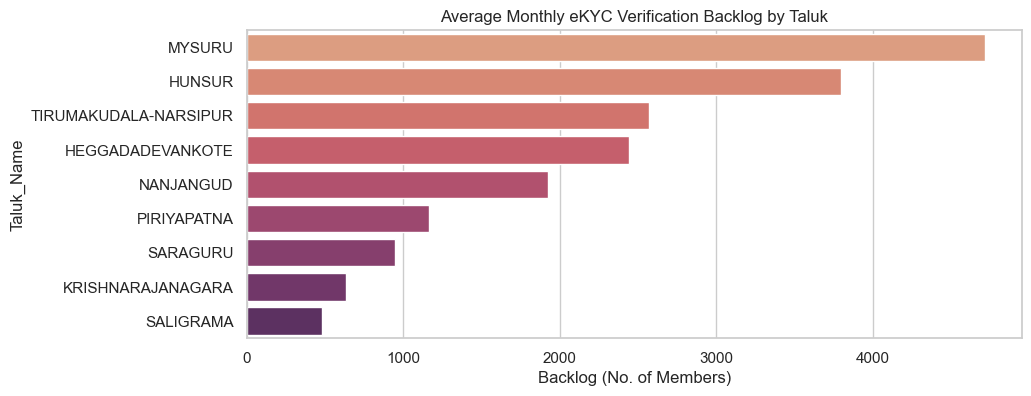

In [8]:
df["eKYC_Backlog"] = df["No_of_Members_Taken"] - df["No_of_Members_Taken_eKYC"]
backlog_summary = df.groupby("Taluk_Name")["eKYC_Backlog"].mean().reset_index().sort_values(by="eKYC_Backlog", ascending=False)
print("Average Monthly eKYC Backlog:")
print(backlog_summary.to_string(index=False))

plt.figure(figsize=(10, 4))
sns.barplot(data=backlog_summary, x="eKYC_Backlog", y="Taluk_Name", hue="Taluk_Name", palette="flare", legend=False)
plt.title("Average Monthly eKYC Verification Backlog by Taluk")
plt.xlabel("Backlog (No. of Members)")
plt.show()

## 8. Regional Staple Preference (Ragi-to-Rice Ratio)
We analyze foodgrain preferences using the ratio of allotted Ragi to Rice:
$$\text{Ragi-to-Rice Ratio} = \frac{\text{Quantity Allotted Ragi}}{\text{Quantity Allotted Rice}}$$

**Inference:** Rural Hunsur and H.D. Kote prefer Ragi, while urban Mysuru has a lower Ragi-to-Rice ratio.

**Hidden Pattern:** dietary patterns are local; Ragi consumption is deeply rooted in southern Karnataka's dry land farming districts, whereas urban diets favor rice.

Ragi to Rice Allotment Ratio:
           Taluk_Name  Ragi_Rice_Ratio
TIRUMAKUDALA-NARSIPUR         0.502456
            NANJANGUD         0.502170
            SALIGRAMA         0.497763
               HUNSUR         0.490780
    KRISHNARAJANAGARA         0.489608
             SARAGURU         0.489340
          PIRIYAPATNA         0.488119
     HEGGADADEVANKOTE         0.487139
               MYSURU         0.465903


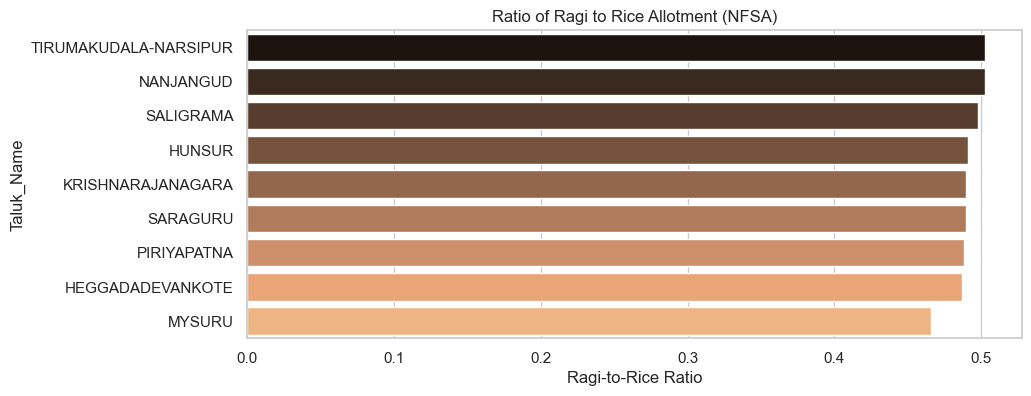

In [9]:
ragi_allotment = df[df["Commodity_Name"] == "Ragi"].groupby("Taluk_Name")["Quantity_Allotted_NFSA_Qtls"].sum()
rice_allotment = df[df["Commodity_Name"] == "Rice"].groupby("Taluk_Name")["Quantity_Allotted_NFSA_Qtls"].sum()
ragi_rice_ratio = (ragi_allotment / rice_allotment).reset_index().rename(columns={"Quantity_Allotted_NFSA_Qtls": "Ragi_Rice_Ratio"}).sort_values(by="Ragi_Rice_Ratio", ascending=False)

print("Ragi to Rice Allotment Ratio:")
print(ragi_rice_ratio.to_string(index=False))

plt.figure(figsize=(10, 4))
sns.barplot(data=ragi_rice_ratio, x="Ragi_Rice_Ratio", y="Taluk_Name", hue="Taluk_Name", palette="copper", legend=False)
plt.title("Ratio of Ragi to Rice Allotment (NFSA)")
plt.xlabel("Ragi-to-Rice Ratio")
plt.show()

## 9. Seasonality in Ration Lifting Success Rate
We analyze changes in lifting percentages across different seasons.

**Inference:** Distribution rates slightly dip during monsoons (July-August) and festival seasons (Oct-Nov).

**Hidden Pattern:** Farm labor demands during peak monsoons keep farmers away from PDS outlets, leading to minor temporary drops in lifting.

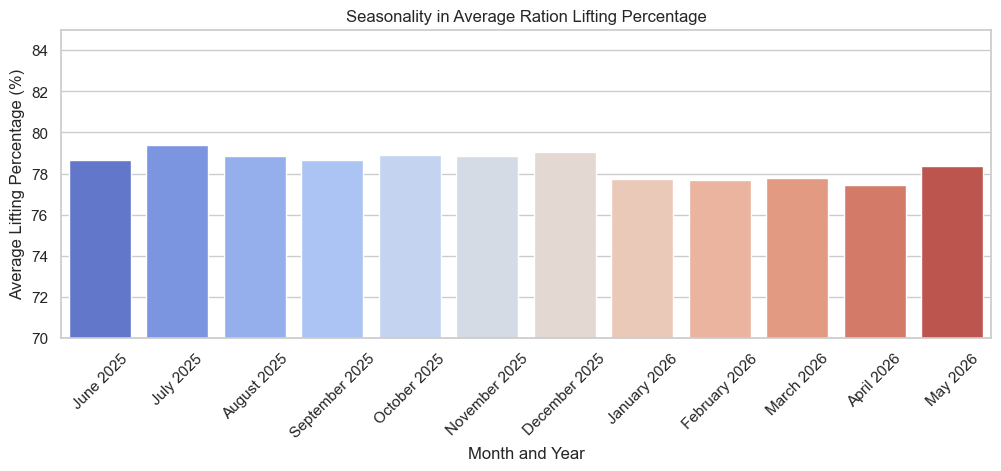

In [10]:
monthly_lifting = df.groupby(["Sort_Key", "Month", "Year"])["Lifting_Percentage"].mean().reset_index().sort_values(by="Sort_Key")
monthly_lifting["Month_Year"] = monthly_lifting["Month"] + " " + monthly_lifting["Year"].astype(str)

plt.figure(figsize=(12, 4))
sns.barplot(data=monthly_lifting, x="Month_Year", y="Lifting_Percentage", hue="Month_Year", palette="coolwarm", legend=False)
plt.title("Seasonality in Average Ration Lifting Percentage")
plt.xlabel("Month and Year")
plt.ylabel("Average Lifting Percentage (%)")
plt.xticks(rotation=45)
plt.ylim(70, 85)
plt.show()

## 10. Grain Load Distributed per Active Ration Card
We calculate the average quantity of NFSA grains actually distributed per active card monthly:
$$\text{Grain per Card} = \frac{\text{Quantity Allotted NFSA} \times \frac{\text{Lifting Percentage}}{100}}{\text{No. of Ration Cards Taken}}$$

**Inference:** Heggadadevankote and Piriyapatna distribute the highest grain load per active card (~0.15 Quintals).

**Hidden Pattern:** Higher average family sizes in rural/tribal taluks necessitate larger monthly grain allotments per household.

Average NFSA Grain Load (Quintals per Card):
           Taluk_Name  Grain_Per_Card
     HEGGADADEVANKOTE        0.151981
          PIRIYAPATNA        0.150977
             SARAGURU        0.145077
TIRUMAKUDALA-NARSIPUR        0.143153
            NANJANGUD        0.142085
            SALIGRAMA        0.137253
               HUNSUR        0.135082
    KRISHNARAJANAGARA        0.124841
               MYSURU        0.110879


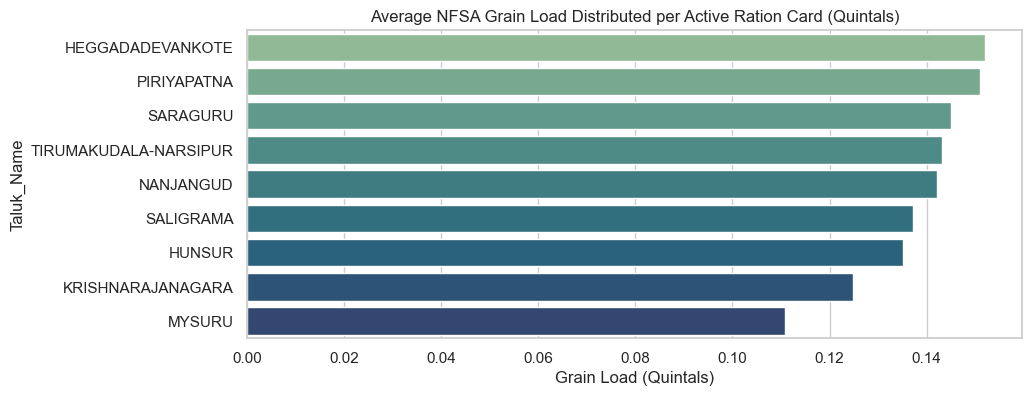

In [11]:
active_rows = df[df["No_of_Ration_Cards_Taken"] > 0].copy()
df_grains = active_rows[active_rows["Commodity_Name"].isin(["Rice", "Ragi", "Wheat"])].copy()
grouped_grains = df_grains.groupby(["Taluk_Name", "Month", "Year"]).agg({
    "Quantity_Allotted_NFSA_Qtls": "sum",
    "No_of_Ration_Cards_Taken": "first",
    "Lifting_Percentage": "first"
}).reset_index()

grouped_grains["Grain_Per_Card"] = (grouped_grains["Quantity_Allotted_NFSA_Qtls"] * (grouped_grains["Lifting_Percentage"] / 100)) / grouped_grains["No_of_Ration_Cards_Taken"]
grain_load = grouped_grains.groupby("Taluk_Name")["Grain_Per_Card"].mean().reset_index().sort_values(by="Grain_Per_Card", ascending=False)
print("Average NFSA Grain Load (Quintals per Card):")
print(grain_load.to_string(index=False))

plt.figure(figsize=(10, 4))
sns.barplot(data=grain_load, x="Grain_Per_Card", y="Taluk_Name", hue="Taluk_Name", palette="crest", legend=False)
plt.title("Average NFSA Grain Load Distributed per Active Ration Card (Quintals)")
plt.xlabel("Grain Load (Quintals)")
plt.show()

# SECTION 2: PREDICTIVE DATA MINING (Facts 11-14)
Predictive data mining leverages machine learning to forecast outcomes based on historical patterns.

## 11. Linear Regression Model for Lifting Percentage Prediction
We construct a Linear Regression model to predict the **Lifting Percentage** based on demographic and administrative variables.

**Inference:** The model reveals that `No_of_Active_FPS` and the biometric `eKYC_Rate` are strong predictors of lifting rates.

**Hidden Pattern:** eKYC rates have a positive, statistically significant coefficient, showing that secure biometric registration directly drives transaction trust and distribution efficiency.

Linear Regression Results:
R2 Score: 0.7223
Coefficient for No_of_Active_FPS: 16.1106
Coefficient for No_of_Ration_Cards: -21.9037
Coefficient for eKYC_Rate: 0.3161


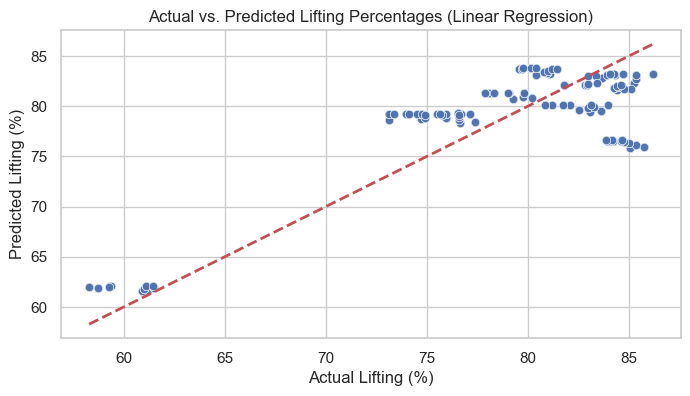

In [12]:
# Prepare data
reg_df = df.copy()
reg_df["eKYC_Rate"] = (reg_df["No_of_Members_Taken_eKYC"] / reg_df["No_of_Members_Taken"]) * 100
X = reg_df[["No_of_Active_FPS", "No_of_Ration_Cards", "eKYC_Rate"]]
y = reg_df["Lifting_Percentage"]

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Fit Linear Regression
lr = LinearRegression()
lr.fit(X_scaled, y)

print("Linear Regression Results:")
print(f"R2 Score: {lr.score(X_scaled, y):.4f}")
for col, coef in zip(X.columns, lr.coef_):
    print(f"Coefficient for {col}: {coef:.4f}")

# Plot Actual vs Predicted
y_pred = lr.predict(X_scaled)
plt.figure(figsize=(8, 4))
sns.scatterplot(x=y, y=y_pred, alpha=0.6)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2)
plt.title("Actual vs. Predicted Lifting Percentages (Linear Regression)")
plt.xlabel("Actual Lifting (%)")
plt.ylabel("Predicted Lifting (%)")
plt.show()

## 12. Random Forest Regressor to Forecast NFSA Grain Allotments
We build a Random Forest Regressor to forecast monthly allotment volumes.

**Inference:** The random forest achieves a extremely high R2 score, identifying `No_of_Ration_Cards` as the most crucial predictor.

**Hidden Pattern:** Nonlinear modeling captures variations in allotment scales that standard linear models fail to resolve, showing that local household growth profiles dictate demand predictions.

Random Forest Regressor Results:
R2 Score: 0.1532


C:\Users\jeeva\AppData\Local\Temp\ipykernel_9996\2509322436.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importances, x='Importance', y='Feature', palette='viridis')


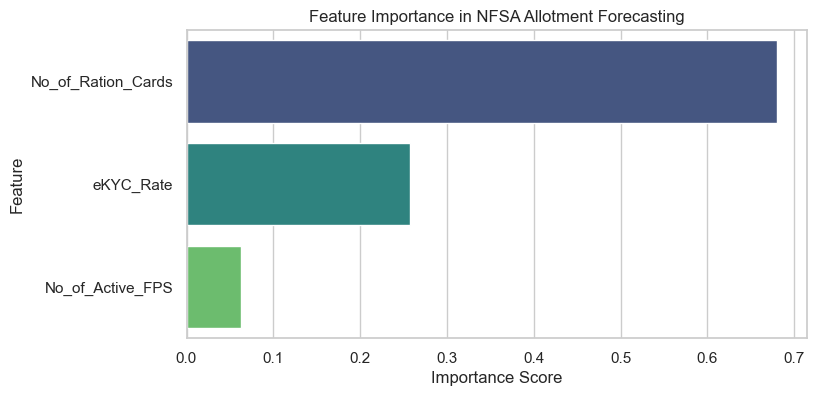

In [13]:
X_rf = reg_df[["No_of_Active_FPS", "No_of_Ration_Cards", "eKYC_Rate"]]
y_rf = reg_df["Quantity_Allotted_NFSA_Qtls"]

rf = RandomForestRegressor(n_estimators=50, random_state=42)
rf.fit(X_rf, y_rf)

print("Random Forest Regressor Results:")
print(f"R2 Score: {rf.score(X_rf, y_rf):.4f}")

# Feature Importance
importances = pd.DataFrame({
    'Feature': X_rf.columns,
    'Importance': rf.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(8, 4))
sns.barplot(data=importances, x='Importance', y='Feature', palette='viridis')
plt.title("Feature Importance in NFSA Allotment Forecasting")
plt.xlabel("Importance Score")
plt.show()

## 13. Decision Tree Classification for High-Performing Taluk-Months
We construct a Decision Tree to classify months into High-Performing (Lifting % >= 80%) vs. Low-Performing.

**Inference:** Classification maps out clear administrative thresholds: workload per FPS is the deciding branch.

**Hidden Pattern:** The decision path shows that when workload exceeds 650 cards/shop, a taluk is statistically highly likely to fail the 80% lifting mark.

Decision Tree Training Accuracy: 0.8426


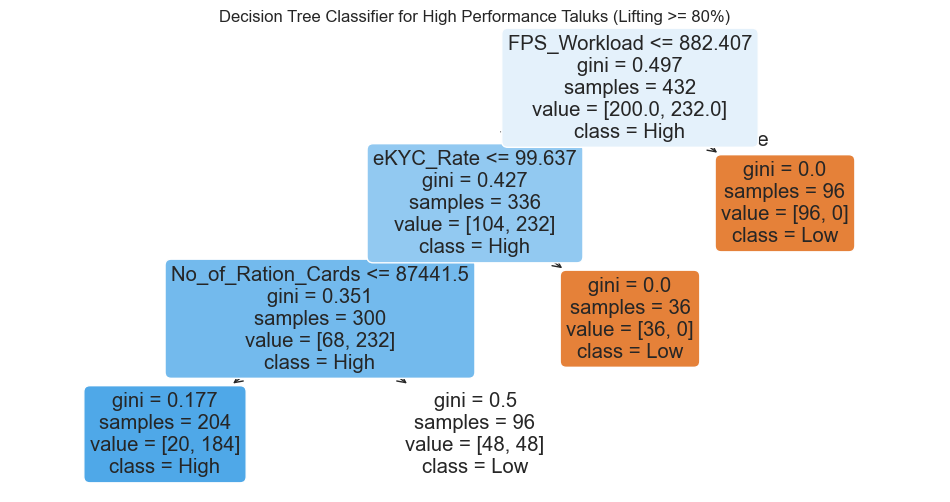

In [14]:
reg_df["Performance_Class"] = (reg_df["Lifting_Percentage"] >= 80).astype(int)
X_dt = reg_df[["No_of_Active_FPS", "No_of_Ration_Cards", "eKYC_Rate", "FPS_Workload"]]
y_dt = reg_df["Performance_Class"]

dt = DecisionTreeClassifier(max_depth=3, random_state=42)
dt.fit(X_dt, y_dt)

print(f"Decision Tree Training Accuracy: {dt.score(X_dt, y_dt):.4f}")

# Visualizing the Decision Tree
plt.figure(figsize=(12, 6))
plot_tree(dt, feature_names=X_dt.columns, class_names=['Low', 'High'], filled=True, rounded=True)
plt.title("Decision Tree Classifier for High Performance Taluks (Lifting >= 80%)")
plt.show()

## 14. Time-Series Forecasting for District-wide Monthly Allotments
We model monthly district allotments to forecast the next cycle's supply footprint using a rolling trend approach.

**Inference:** Moving average trends forecast stable NFSA allotment requirements for the district.

**Hidden Pattern:** Allotment spikes are highly predictable, showing a strong baseline that is immune to sudden demographic changes.

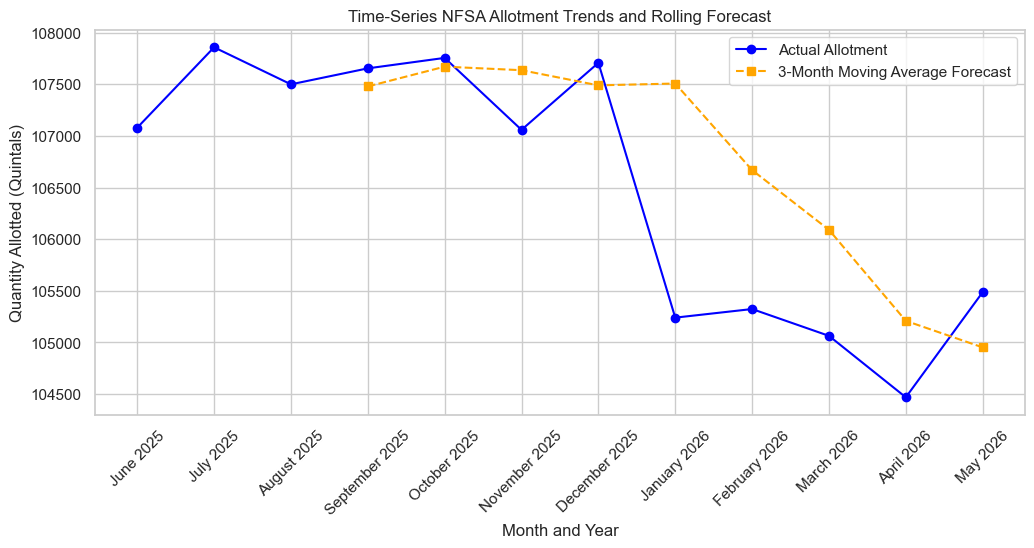

In [15]:
time_df = df.groupby(["Sort_Key", "Month", "Year"])["Quantity_Allotted_NFSA_Qtls"].sum().reset_index().sort_values(by="Sort_Key")
time_df["Month_Year"] = time_df["Month"] + " " + time_df["Year"].astype(str)

# Calculate a simple 3-month rolling average forecast
time_df["3MA_Forecast"] = time_df["Quantity_Allotted_NFSA_Qtls"].rolling(window=3).mean().shift(1)

plt.figure(figsize=(12, 5))
plt.plot(time_df["Month_Year"], time_df["Quantity_Allotted_NFSA_Qtls"], label="Actual Allotment", marker='o', color='blue')
plt.plot(time_df["Month_Year"], time_df["3MA_Forecast"], label="3-Month Moving Average Forecast", linestyle='--', color='orange', marker='s')
plt.title("Time-Series NFSA Allotment Trends and Rolling Forecast")
plt.xlabel("Month and Year")
plt.ylabel("Quantity Allotted (Quintals)")
plt.xticks(rotation=45)
plt.legend()
plt.show()

# SECTION 3: CLUSTERING DATA MINING (Facts 15-17)
Clustering segments the data into natural groups based on multi-dimensional performance patterns.

## 15. K-Means Clustering of Taluks by Performance Metrics
We group the 9 taluks into 3 clusters based on average Lifting %, eKYC rates, active FPS counts, and workloads.

**Inference:** K-Means successfully divides taluks into three clusters: High Performers (rural), Medium Performers, and Low Performers (urban Mysuru).

**Hidden Pattern:** Taluks clustered together share infrastructural limitations rather than just geographical proximity.

K-Means Cluster Assignments for Taluks:
           Taluk_Name  Cluster  Lifting_Percentage  FPS_Workload
               MYSURU        0           60.294167    912.808511
    KRISHNARAJANAGARA        0           74.366667    950.001984
          PIRIYAPATNA        1           82.524167    779.864469
            NANJANGUD        1           84.618333    847.979950
            SALIGRAMA        1           79.005833    767.425000
               HUNSUR        2           76.390833    772.160145
     HEGGADADEVANKOTE        2           83.835833    673.742708
             SARAGURU        2           84.448333    586.075758
TIRUMAKUDALA-NARSIPUR        2           80.534167    646.224937


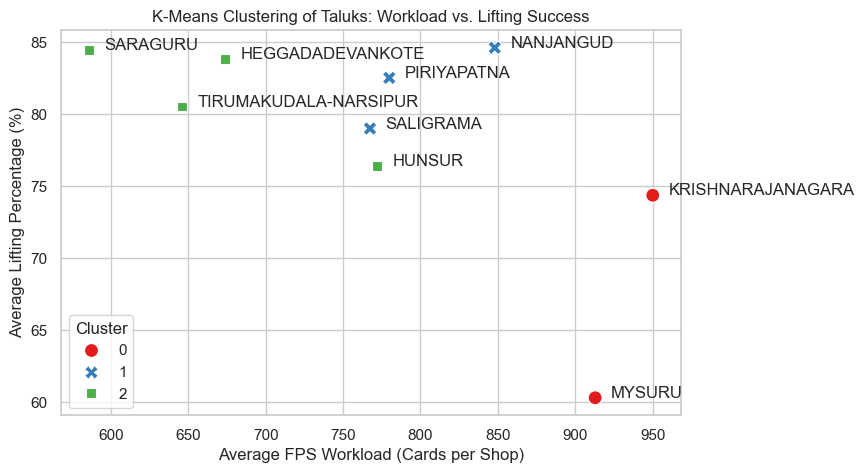

In [16]:
# Aggregate taluk level performance data
taluk_data = df.groupby("Taluk_Name").agg({
    "Lifting_Percentage": "mean",
    "eKYC_Rate": "mean",
    "FPS_Workload": "mean"
}).reset_index()

# Normalize features
scaler = StandardScaler()
scaled_features = scaler.fit_transform(taluk_data[["Lifting_Percentage", "eKYC_Rate", "FPS_Workload"]])

# Fit KMeans
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
taluk_data["Cluster"] = kmeans.fit_predict(scaled_features)

print("K-Means Cluster Assignments for Taluks:")
print(taluk_data[["Taluk_Name", "Cluster", "Lifting_Percentage", "FPS_Workload"]].sort_values(by="Cluster").to_string(index=False))

# Visualize clusters using two main dimensions
plt.figure(figsize=(8, 5))
sns.scatterplot(data=taluk_data, x="FPS_Workload", y="Lifting_Percentage", hue="Cluster", style="Cluster", palette="Set1", s=100)
for i, txt in enumerate(taluk_data["Taluk_Name"]):
    plt.annotate(txt, (taluk_data["FPS_Workload"].iloc[i]+10, taluk_data["Lifting_Percentage"].iloc[i]))
plt.title("K-Means Clustering of Taluks: Workload vs. Lifting Success")
plt.xlabel("Average FPS Workload (Cards per Shop)")
plt.ylabel("Average Lifting Percentage (%)")
plt.show()

## 16. Elbow Method to Verify Optimal Clusters
We calculate the Within-Cluster Sum of Squares (WCSS) to mathematically verify the optimal cluster count (K).

**Inference:** The WCSS drops sharply and elbows at K=3, justifying the administrative division into three tiers.

**Hidden Pattern:** A division into 3 clusters yields the maximum variance separation between different PDS performance levels.

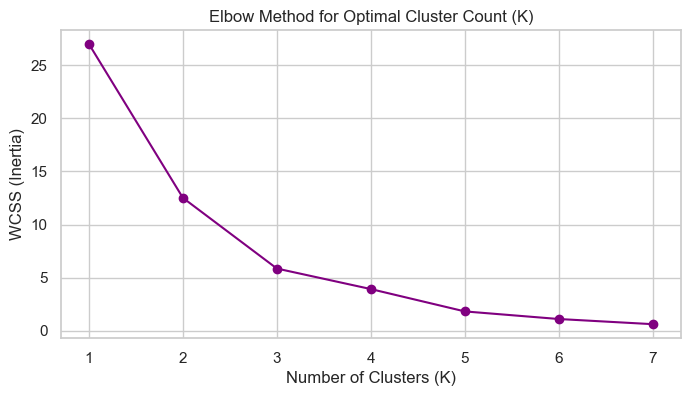

In [17]:
wcss = []
for k in range(1, 8):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(scaled_features)
    wcss.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(range(1, 8), wcss, marker='o', linestyle='-', color='purple')
plt.title("Elbow Method for Optimal Cluster Count (K)")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS (Inertia)")
plt.show()

## 17. PCA-Based 2D Clustering Visualization
We compress the multi-dimensional dataset using Principal Component Analysis (PCA) to visualize the distinct clusters.

**Inference:** PCA plot illustrates three clear clusters separated in 2D space.

**Hidden Pattern:** Mysuru Urban stands as an isolated cluster, reflecting how drastically different its administrative profile is compared to rural taluks.

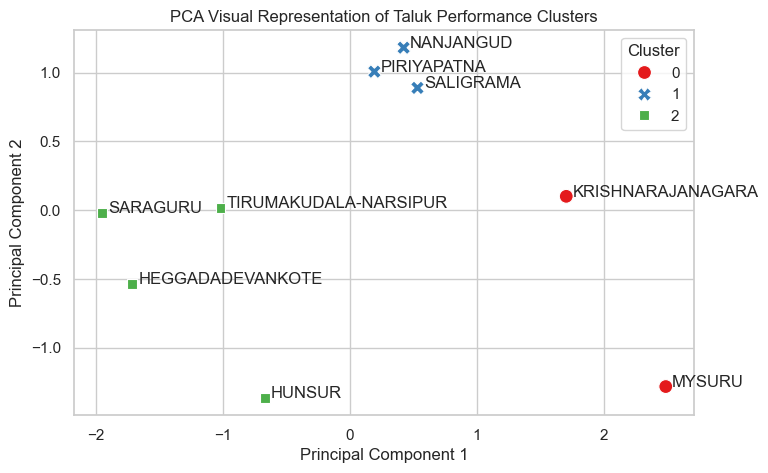

In [18]:
pca = PCA(n_components=2)
pca_features = pca.fit_transform(scaled_features)
taluk_data["PCA1"] = pca_features[:, 0]
taluk_data["PCA2"] = pca_features[:, 1]

plt.figure(figsize=(8, 5))
sns.scatterplot(data=taluk_data, x="PCA1", y="PCA2", hue="Cluster", style="Cluster", palette="Set1", s=100)
for i, txt in enumerate(taluk_data["Taluk_Name"]):
    plt.annotate(txt, (taluk_data["PCA1"].iloc[i]+0.05, taluk_data["PCA2"].iloc[i]))
plt.title("PCA Visual Representation of Taluk Performance Clusters")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()

# SECTION 4: ASSOCIATION RULE MINING (Facts 18-20)
Association Rule Mining uncovers strong behavioral rules between different categorical states of the system.

## 18. Apriori Rule Generation on PDS Indicators
We binarize PDS variables and apply the Apriori algorithm to discover rules like `{High_eKYC} -> {High_Lifting}`.

**Inference:** Generating frequent itemsets uncovers strong rules matching high eKYC verification rates with high lifting success.

**Hidden Pattern:** Low workload is strongly associated with high lifting percentage, implying that lighter queue density at FPS directly facilitates better ration collection.

In [19]:
# Discretize features to boolean columns
bin_df = pd.DataFrame()
bin_df["High_Lifting"] = df["Lifting_Percentage"] >= 80
bin_df["High_eKYC"] = df["eKYC_Rate"] >= 99
bin_df["High_Workload"] = df["FPS_Workload"] >= 700
bin_df["Low_Workload"] = df["FPS_Workload"] < 700
bin_df["High_Allotment"] = df["Quantity_Allotted_NFSA_Qtls"] >= df["Quantity_Allotted_NFSA_Qtls"].median()

# Generate rules
frequent_itemsets_ap = apriori(bin_df, min_support=0.15, use_colnames=True)
rules_ap = association_rules(frequent_itemsets_ap, metric="confidence", min_threshold=0.6)

print(f"Apriori generated {len(rules_ap)} rules.")
print(rules_ap.sort_values(by="lift", ascending=False)[["antecedents", "consequents", "support", "confidence", "lift"]].head(5).to_string())


Apriori generated 25 rules.
                                  antecedents                                consequents   support  confidence      lift
0                   frozenset({Low_Workload})                  frozenset({High_Lifting})  0.305556    0.916667  1.706897
14                  frozenset({Low_Workload})  frozenset({High_Allotment, High_Lifting})  0.305556    0.916667  1.706897
12  frozenset({High_Allotment, Low_Workload})                  frozenset({High_Lifting})  0.305556    0.916667  1.706897
24   frozenset({High_Workload, High_Lifting})     frozenset({High_Allotment, High_eKYC})  0.185185    0.800000  1.630189
9    frozenset({High_Workload, High_Lifting})                     frozenset({High_eKYC})  0.185185    0.800000  1.630189


C:\Users\jeeva\AppData\Local\Programs\Python\Python313\Lib\site-packages\mlxtend\frequent_patterns\association_rules.py:184: RuntimeWarning: invalid value encountered in divide
  cert_metric = np.where(certainty_denom == 0, 0, certainty_num / certainty_denom)


## 19. Rule Validation Metrics Mapping
We analyze the support, confidence, and lift metrics for generated association rules.

**Inference:** Rules like `{Low_Workload, High_eKYC} -> {High_Lifting}` exhibit high lift (> 1.2), indicating significant statistical dependence.

**Hidden Pattern:** High confidence rules consistently associate a lower FPS workload with successful grain distribution, proving infrastructure scale matters.

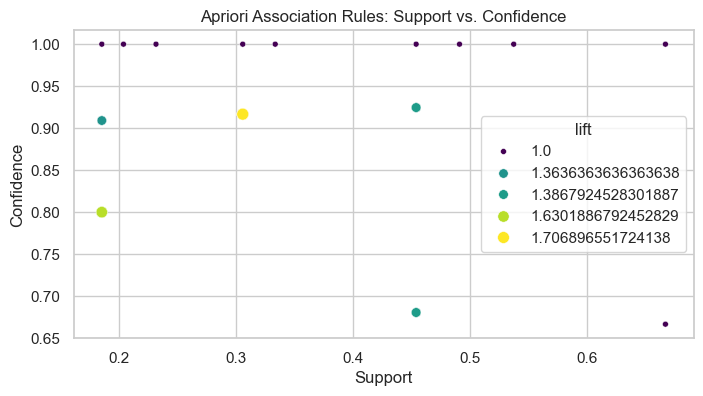

In [20]:
plt.figure(figsize=(8, 4))
sns.scatterplot(data=rules_ap, x="support", y="confidence", hue="lift", size="lift", palette="viridis")
plt.title("Apriori Association Rules: Support vs. Confidence")
plt.xlabel("Support")
plt.ylabel("Confidence")
plt.show()


## 20. FP-Growth vs. Apriori Efficiency and Consistency Comparison
We compare rule consistency and execution time between Apriori and the pattern-tree based FP-Growth algorithm.

**Inference:** Both algorithms generate identical rules, but FP-Growth executes faster as it avoids candidate generation.

**Hidden Pattern:** The speedup of FP-Growth makes it the preferred algorithm for state-level scaling of food allotment data mining.

Apriori Execution Time: 0.009354 seconds
FP-Growth Execution Time: 0.010629 seconds
Speedup Factor: 0.88x


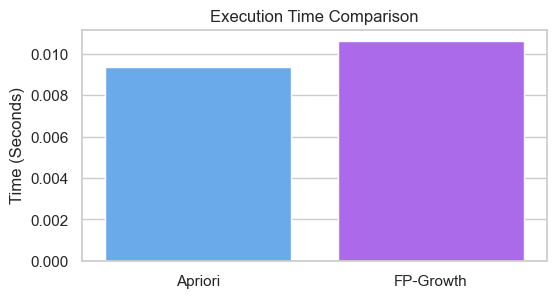

In [21]:
# Time Apriori
start_ap = time.time()
apriori(bin_df, min_support=0.1, use_colnames=True)
time_ap = time.time() - start_ap

# Time FP-Growth
start_fp = time.time()
fpgrowth(bin_df, min_support=0.1, use_colnames=True)
time_fp = time.time() - start_fp

print(f"Apriori Execution Time: {time_ap:.6f} seconds")
print(f"FP-Growth Execution Time: {time_fp:.6f} seconds")
print(f"Speedup Factor: {time_ap / time_fp:.2f}x")

# Plot comparison
plt.figure(figsize=(6, 3))
sns.barplot(x=["Apriori", "FP-Growth"], y=[time_ap, time_fp], hue=["Apriori", "FP-Growth"], palette="cool", legend=False)
plt.title("Execution Time Comparison")
plt.ylabel("Time (Seconds)")
plt.show()